In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter
import kagglehub
from sklearn.decomposition import PCA
import numpy as np
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from PIL import Image, ImageEnhance
import random
from pathlib import Path
import seaborn as sns


In [2]:

# Funkcja augmentacji
def augment_image(img):
    # Obrót ±15 stopni
    angle = random.uniform(-15, 15)
    img = img.rotate(angle)

    # Odbicie lustrzane
    if random.random() > 0.5:
        img = img.transpose(Image.FLIP_LEFT_RIGHT)

    # Jasność
    enhancer = ImageEnhance.Brightness(img)
    img = enhancer.enhance(random.uniform(0.8, 1.2))

    # Kontrast
    enhancer = ImageEnhance.Contrast(img)
    img = enhancer.enhance(random.uniform(0.8, 1.2))

    return img

In [3]:
# path = kagglehub.dataset_download("nikolasgegenava/cat-breeds")
path = kagglehub.dataset_download("imbikramsaha/cat-breeds")

print("Path to dataset files:", path)

100%|██████████| 208M/208M [01:16<00:00, 2.84MB/s] 

Extracting files...


Path to dataset files: C:\Users\Cezary\.cache\kagglehub\datasets\imbikramsaha\cat-breeds\versions\1


In [6]:
image_paths = []
labels = []
img_path = path + '\\cats-breads'
# thai somali sokoke singapura siberian serengeti savannah safari munchkin korean_bobtail karelian_bobtail lykoi himalayan havana_brown donskoy cyprus burmese bombay balinese

# unallowed_breeds = [
#     "thai", "somali", "sokoke", "singapura", "siberian", 
#     "serengeti", "savannah", "safari", "munchkin", 
#     "korean_bobtail", "karelian_bobtail", "lykoi", 
#     "himalayan", "havana_brown", "donskoy", "cyprus", 
#     "burmese", "bombay", "balinese"
# ]

for breed in os.listdir(img_path):
    # if breed in unallowed_breeds:
    #     continue  # pomijamy klasy z listy

    breed_path = os.path.join(img_path, breed)
    if os.path.isdir(breed_path):
        for img in os.listdir(breed_path):
            if img.lower().endswith(".jpg"):  # tylko pliki .jpg
                image_paths.append(os.path.join(breed_path, img))
                labels.append(breed)

df = pd.DataFrame({
    "image_path": image_paths,
    "breed": labels
})

print(df.head())
print("Liczba obrazów:", len(df))

                                          image_path       breed
0  C:\Users\Cezary\.cache\kagglehub\datasets\imbi...  Abyssinian
1  C:\Users\Cezary\.cache\kagglehub\datasets\imbi...  Abyssinian
2  C:\Users\Cezary\.cache\kagglehub\datasets\imbi...  Abyssinian
3  C:\Users\Cezary\.cache\kagglehub\datasets\imbi...  Abyssinian
4  C:\Users\Cezary\.cache\kagglehub\datasets\imbi...  Abyssinian
Liczba obrazów: 2388


In [9]:
IMG_SIZE = (64, 64)

X = []
y = []

for _, row in df.iterrows():
    img = Image.open(row["image_path"]).convert("RGB")
    img = img.resize(IMG_SIZE)

    img_array = np.array(img)
    X.append(img_array.flatten())

    y.append(row["breed"])

X = np.array(X)
y = np.array(y)


12
breed
Abyssinian           200
Bengal               200
Birman               200
Bombay               200
British_Shorthair    200
Egyptian_Mau         200
Maine_Coon           200
Persian              200
Russian_Blue         200
Siamese              200
Sphynx               200
Ragdoll              188
Name: count, dtype: int64


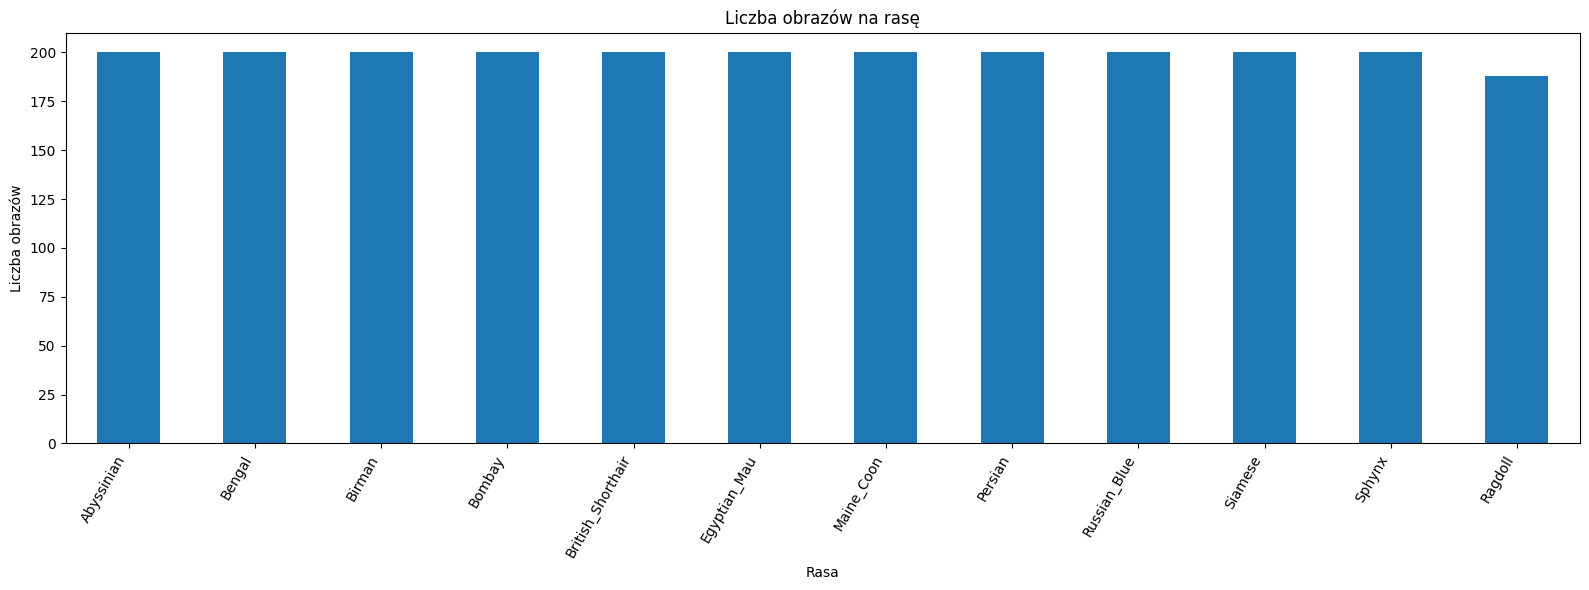

In [7]:
breed_counts = df["breed"].value_counts()

print(len(breed_counts))
print(breed_counts)

plt.figure(figsize=(16,6)) 
breed_counts.plot(kind="bar")

plt.title("Liczba obrazów na rasę")
plt.xlabel("Rasa")
plt.ylabel("Liczba obrazów")

plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

In [8]:

widths = []
heights = []
extensions = []

for path_img in df["image_path"]:
    with Image.open(path_img) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)

    extensions.append(Path(path_img).suffix.lower())

width_mode = Counter(widths).most_common(1)[0]
height_mode = Counter(heights).most_common(1)[0]

# statystyki rozdzielczości
print("Szerokość:")
print("średnia:", np.mean(widths))
print("mediana:", np.median(widths))
print("moda:", width_mode)
print("min:", np.min(widths))
print("max:", np.max(widths))

print("\nWysokość:")
print("średnia:", np.mean(heights))
print("mediana:", np.median(heights))
print("moda:", height_mode)
print("min:", np.min(heights))
print("max:", np.max(heights))

# rozszerzenia plików
ext_counts = Counter(extensions)

print("\nRozszerzenia plików:")
for ext, count in ext_counts.items():
    print(ext, ":", count)



Szerokość:
średnia: 437.6494974874372
mediana: 500.0
moda: (500, 1142)
min: 114
max: 3264

Wysokość:
średnia: 391.47613065326635
mediana: 375.0
moda: (500, 583)
min: 103
max: 2606

Rozszerzenia plików:
.jpg : 2388


In [10]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
n_classes = len(np.unique(y_encoded))

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=2137
)

In [11]:
# Standaryzacja
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Redukcje wymiarów
reducers = {
    "PCA": PCA(n_components=50),
    "LDA": LinearDiscriminantAnalysis(n_components=int(n_classes - 1))
}

X_train_reduced = {}
X_test_reduced = {}

for red_name, reducer in reducers.items():
    print(f"Redukcja wymiarów: {red_name}")
    X_train_reduced[red_name] = reducer.fit_transform(X_train_scaled, y_train if red_name=="LDA" else None)
    X_test_reduced[red_name] = reducer.transform(X_test_scaled)

# Klasyfikatory
classifiers = {
    "SVM": SVC(kernel="rbf"),
    "Decision Tree": DecisionTreeClassifier(max_depth=10),
    "XGBoost": XGBClassifier(objective="multi:softmax", num_class=n_classes, eval_metric="mlogloss")
}

# Trenowanie wszystkich klasyfikatorów na zredukowanych danych
results = []

for red_name in reducers.keys():
    X_tr = X_train_reduced[red_name]
    X_te = X_test_reduced[red_name]
    
    for clf_name, clf in classifiers.items():
        print(f"Trening: {red_name} + {clf_name}")
        clf.fit(X_tr, y_train)
        y_pred = clf.predict(X_te)
        acc = accuracy_score(y_test, y_pred)
        results.append({
            "Reduction": red_name,
            "Classifier": clf_name,
            "Accuracy": acc
        })
        print(f"Accuracy: {acc:.4f}\n")

# Porównanie wyników
df_results = pd.DataFrame(results)
print(df_results.pivot(index="Reduction", columns="Classifier", values="Accuracy"))

Redukcja wymiarów: PCA
Redukcja wymiarów: LDA
Trening: PCA + SVM
Accuracy: 0.3201

Trening: PCA + Decision Tree
Accuracy: 0.2134

Trening: PCA + XGBoost
Accuracy: 0.2636

Trening: LDA + SVM
Accuracy: 0.0983

Trening: LDA + Decision Tree
Accuracy: 0.1318

Trening: LDA + XGBoost
Accuracy: 0.1025

Classifier  Decision Tree       SVM   XGBoost
Reduction                                    
LDA              0.131799  0.098326  0.102510
PCA              0.213389  0.320084  0.263598


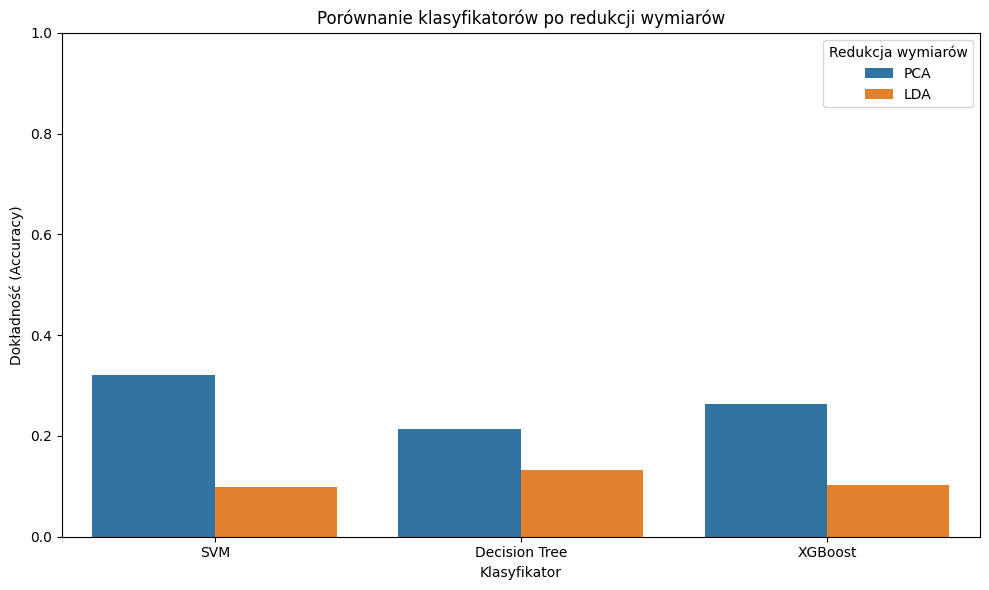

In [12]:

# Przygotowanie danych do wykresu
df_plot = df_results.copy()
plt.figure(figsize=(10,6))

sns.barplot(
    data=df_plot,
    x="Classifier",
    y="Accuracy",
    hue="Reduction"
)

plt.title("Porównanie klasyfikatorów po redukcji wymiarów")
plt.ylim(0,1)
plt.ylabel("Dokładność (Accuracy)")
plt.xlabel("Klasyfikator")
plt.legend(title="Redukcja wymiarów")
plt.tight_layout()
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=2137
)

In [16]:
n_augments = 4

# Nowe zbiory
X_train_aug = []
y_train_aug = []

for i in range(len(X_train)):
    # Oryginał
    X_train_aug.append(X_train[i])
    y_train_aug.append(y_train[i])
    
    # Zamiana z powrotem na PIL Image, żeby augmentować
    img = Image.fromarray(X_train[i].reshape(IMG_SIZE[1], IMG_SIZE[0], 3))
    
    for _ in range(n_augments):
        img_aug = augment_image(img)
        X_train_aug.append(np.array(img_aug).flatten())
        y_train_aug.append(y_train[i])

# Zamiana na numpy array
X_train_aug = np.array(X_train_aug)
y_train_aug = np.array(y_train_aug)

print("Rozmiar treningowego po augmentacji:", X_train_aug.shape)
print("Rozmiar testowego (bez augmentacji):", X_test.shape)

X_train = X_train_aug
y_train = y_train_aug


Rozmiar treningowego po augmentacji: (28650, 12288)
Rozmiar testowego (bez augmentacji): (478, 12288)


In [17]:
# Kod przygotowujący dane
le = LabelEncoder()
y_encoded = le.fit_transform(y)
n_classes = len(np.unique(y_encoded))

# Standaryzacja
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Redukcje wymiarów
reducers = {
    "PCA": PCA(n_components=10),
    # "LDA": LinearDiscriminantAnalysis(n_components=30)
}

X_train_reduced = {}
X_test_reduced = {}

for red_name, reducer in reducers.items():
    print(f"Redukcja wymiarów: {red_name}")
    X_train_reduced[red_name] = reducer.fit_transform(X_train_scaled, y_train if red_name=="LDA" else None)
    X_test_reduced[red_name] = reducer.transform(X_test_scaled)

# Klasyfikatory
classifiers = {
    "SVM": SVC(kernel="rbf"),
    "Decision Tree": DecisionTreeClassifier(max_depth=10),
    "XGBoost": XGBClassifier(objective="multi:softmax", num_class=n_classes, eval_metric="mlogloss")
}

# Trenowanie wszystkich klasyfikatorów na zredukowanych danych
results = []

for red_name in reducers.keys():
    X_tr = X_train_reduced[red_name]
    X_te = X_test_reduced[red_name]
    
    for clf_name, clf in classifiers.items():
        print(f"Trening: {red_name} + {clf_name}")
        
        # Trenowanie
        clf.fit(X_tr, y_train)
        
        # Predykcja
        y_pred_train = clf.predict(X_tr)
        y_pred_test = clf.predict(X_te)
        
        # Dokładności
        acc_train = accuracy_score(y_train, y_pred_train)
        acc_test = accuracy_score(y_test, y_pred_test)
        
        results.append({
            "Reduction": red_name,
            "Classifier": clf_name,
            "Train_Accuracy": acc_train,
            "Test_Accuracy": acc_test
        })
        
        print(f"Train Accuracy: {acc_train:.4f}, Test Accuracy: {acc_test:.4f}\n")

# Porównanie wyników
df_results = pd.DataFrame(results)
print(df_results.pivot(index="Reduction", columns="Classifier", values="Test_Accuracy"))

Redukcja wymiarów: PCA
Trening: PCA + SVM
Train Accuracy: 0.4318, Test Accuracy: 0.2594

Trening: PCA + Decision Tree
Train Accuracy: 0.3757, Test Accuracy: 0.2029

Trening: PCA + XGBoost
Train Accuracy: 0.8852, Test Accuracy: 0.2782

Classifier  Decision Tree       SVM   XGBoost
Reduction                                    
PCA              0.202929  0.259414  0.278243


In [19]:

# Kod przygotowujący dane
le = LabelEncoder()
y_encoded = le.fit_transform(y)
n_classes = len(np.unique(y_encoded))

# Standaryzacja
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Redukcje wymiarów
reducers = {
    "PCA": PCA(n_components=50),
    # "LDA": LinearDiscriminantAnalysis(n_components=30)
}

X_train_reduced = {}
X_test_reduced = {}

for red_name, reducer in reducers.items():
    print(f"Redukcja wymiarów: {red_name}")
    X_train_reduced[red_name] = reducer.fit_transform(X_train_scaled, y_train if red_name=="LDA" else None)
    X_test_reduced[red_name] = reducer.transform(X_test_scaled)

# Klasyfikatory
classifiers = {
    "SVM": SVC(kernel="rbf"),
    "Decision Tree": DecisionTreeClassifier(max_depth=10),
    "XGBoost": XGBClassifier(objective="multi:softmax", num_class=n_classes, eval_metric="mlogloss")
}

# Trenowanie wszystkich klasyfikatorów na zredukowanych danych
results = []

for red_name in reducers.keys():
    X_tr = X_train_reduced[red_name]
    X_te = X_test_reduced[red_name]
    
    for clf_name, clf in classifiers.items():
        print(f"Trening: {red_name} + {clf_name}")
        
        # Trenowanie
        clf.fit(X_tr, y_train)
        
        # Predykcja
        y_pred_train = clf.predict(X_tr)
        y_pred_test = clf.predict(X_te)
        
        # Dokładności
        acc_train = accuracy_score(y_train, y_pred_train)
        acc_test = accuracy_score(y_test, y_pred_test)
        
        results.append({
            "Reduction": red_name,
            "Classifier": clf_name,
            "Train_Accuracy": acc_train,
            "Test_Accuracy": acc_test
        })
        
        print(f"Train Accuracy: {acc_train:.4f}, Test Accuracy: {acc_test:.4f}\n")

# Porównanie wyników
df_results = pd.DataFrame(results)
print(df_results.pivot(index="Reduction", columns="Classifier", values="Test_Accuracy"))

Redukcja wymiarów: PCA
Trening: PCA + SVM
Train Accuracy: 0.8015, Test Accuracy: 0.3494

Trening: PCA + Decision Tree
Train Accuracy: 0.4101, Test Accuracy: 0.1695

Trening: PCA + XGBoost
Train Accuracy: 0.9995, Test Accuracy: 0.3013

Classifier  Decision Tree       SVM   XGBoost
Reduction                                    
PCA              0.169456  0.349372  0.301255
